In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from util.load import DataLoader

In [21]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 300
full_df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="processed"
)
daily_df = dataloader.load_daily_data(ticker, max_days=max_days, type_="processed")
full_df.drop(columns=["time", "ticker", "trade_id"]).head()

Loading kxhighny for 2024-08-16:   0%|          | 0/294 [00:00<?, ?it/s]

Loading kxhighny for 2025-06-05: 100%|██████████| 294/294 [00:00<00:00, 299.83it/s]


,time_to_strike,count,shift,kalshi_fair,forecast,yes_price,no_price,taker_side,kalshi_strike_delta,forecast_strike_delta,...,strike_m_5.0,strike_m_3.0,strike_m_1.0,strike_p_1.0,strike_p_3.0,strike_p_5.0,entropy,impact,result,outcome
0,135720.433,25,1.0,88.5,87.55,38,62,1,0.0,-0.95,...,0.0,0.0,0.0,38.0,0.0,0.0,-138.228,-35.000,-38,0
1,135700.506,11,1.0,88.5,87.55,38,62,1,0.0,-0.95,...,0.0,0.0,0.0,38.0,0.0,0.0,-138.228,-35.097,-38,0
2,135700.506,13,1.0,88.5,87.55,40,60,1,0.0,-0.95,...,0.0,0.0,0.0,40.0,0.0,0.0,-147.555,-37.057,-40,0
3,135608.070,24,1.0,88.5,87.55,39,61,1,0.0,-0.95,...,0.0,0.0,0.0,39.0,0.0,0.0,-142.879,-36.143,-39,0
4,135599.038,24,1.0,88.5,87.55,39,61,1,0.0,-0.95,...,0.0,0.0,0.0,39.0,0.0,0.0,-142.879,-35.544,-39,0


In [22]:
full_df.columns

Index(['time', 'trade_id', 'ticker', 'time_to_strike', 'count', 'shift',
       'kalshi_fair', 'forecast', 'yes_price', 'no_price', 'taker_side',
       'kalshi_strike_delta', 'forecast_strike_delta', 'kalshi_forecast_delta',
       'strike_m_5.0', 'strike_m_3.0', 'strike_m_1.0', 'strike_p_1.0',
       'strike_p_3.0', 'strike_p_5.0', 'entropy', 'impact', 'result',
       'outcome'],
      dtype='object')

In [23]:
df = full_df[
    (full_df['yes_price'] > 1) & 
    (full_df['yes_price'] < 99)
]
df.shape

(391556, 24)

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler


features = [
    'kalshi_strike_delta',
    'kalshi_forecast_delta',
    'forecast_strike_delta',
    "time_to_strike",
    # "entropy",
    'yes_price',
    # "yes_trend",
]

test_size = 0.25
dates = list(daily_df.keys())

test_dates  = dates[-int(test_size * len(dates)):]
train_dates = dates[:-int(test_size * len(dates))]

train_df = pd.concat([daily_df[date] for date in train_dates])

pred_df = {
    'prediction': [],
    'outcome': [],
    'yes_price': [],
}

for date in tqdm(test_dates):
    test_df = daily_df[date]
    knn = KNeighborsClassifier(n_neighbors=125, weights='distance', p=2)
    knn.fit(train_df[features], train_df["outcome"].values)
    pred_df['yes_price'].extend(test_df['yes_price'].values)
    prob = knn.predict_proba(test_df[features])[:, 1]
    pred_df['prediction'].extend(prob)
    pred_df['outcome'].extend(test_df["outcome"].values)
    train_df = pd.concat([train_df, test_df])

pred_df = pd.DataFrame(pred_df)
pred_df.head()

100%|██████████| 73/73 [00:08<00:00,  8.57it/s]


,prediction,outcome,yes_price
0,0.253534,1,40
1,0.324358,1,39
2,0.151645,0,9
3,0.139087,0,7
4,0.154170,0,11


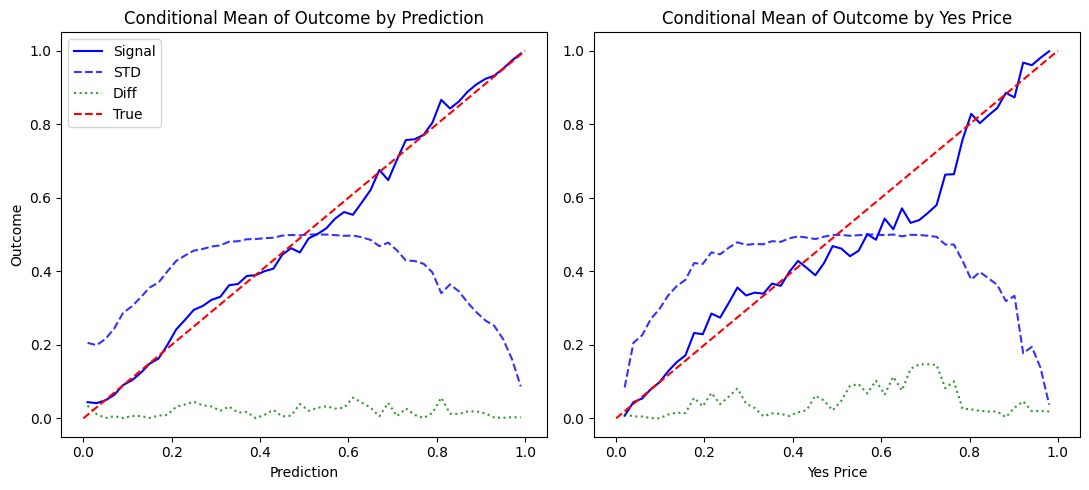

0.018966315031699033 0.04658950299623723


In [39]:
n_buckets = 50

pred_df['pred_buckets'] = pd.cut(pred_df['prediction'], n_buckets)
pred_conditional_mean = pred_df.groupby('pred_buckets')['outcome'].mean()
pred_conditional_std = pred_df.groupby('pred_buckets')['outcome'].std() 
pred_x_values = np.array([(x.left + x.right) / 2 for x in pred_conditional_mean.index.values])
pred_diff = pred_conditional_mean.values - pred_x_values

pred_df['price_buckets'] = pd.cut(pred_df['yes_price'], n_buckets)
price_conditional_mean = pred_df.groupby('price_buckets')['outcome'].mean()
price_conditional_std = pred_df.groupby('price_buckets')['outcome'].std() 
price_x_values = np.array([(x.left + x.right) / 200 for x in price_conditional_mean.index.values])
price_diff = price_conditional_mean.values - price_x_values

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].plot(
    pred_x_values, 
    pred_conditional_mean.values,
    color = 'blue',
    label = 'Signal'
)
ax[0].plot(
    pred_x_values, 
    pred_conditional_std.values,
    color = 'blue',
    linestyle = '--',
    label = 'STD',
    alpha = 0.8
)
ax[0].plot(
    pred_x_values, 
    abs(pred_diff),
    color = 'green',
    linestyle = ':',
    label = 'Diff',
    alpha = 0.8
)
ax[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
ax[0].set_xlabel('Prediction')  
ax[0].set_ylabel('Outcome')
ax[0].set_title('Conditional Mean of Outcome by Prediction')

ax[1].plot(
    price_x_values, 
    price_conditional_mean.values,
    color = 'blue'
)
ax[1].plot(
    price_x_values, 
    price_conditional_std.values,
    color = 'blue',
    linestyle = '--',
    label = 'STD',
    alpha = 0.8
)
ax[1].plot(
    price_x_values, 
    abs(price_diff),
    color = 'green',
    linestyle = ':',
    label = 'Diff',
    alpha = 0.8
)
ax[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='True')
ax[1].set_xlabel('Yes Price')
ax[1].set_title('Conditional Mean of Outcome by Yes Price')

ax[0].legend()
plt.tight_layout()
plt.show()

print(abs(pred_diff).mean(), abs(price_diff).mean())

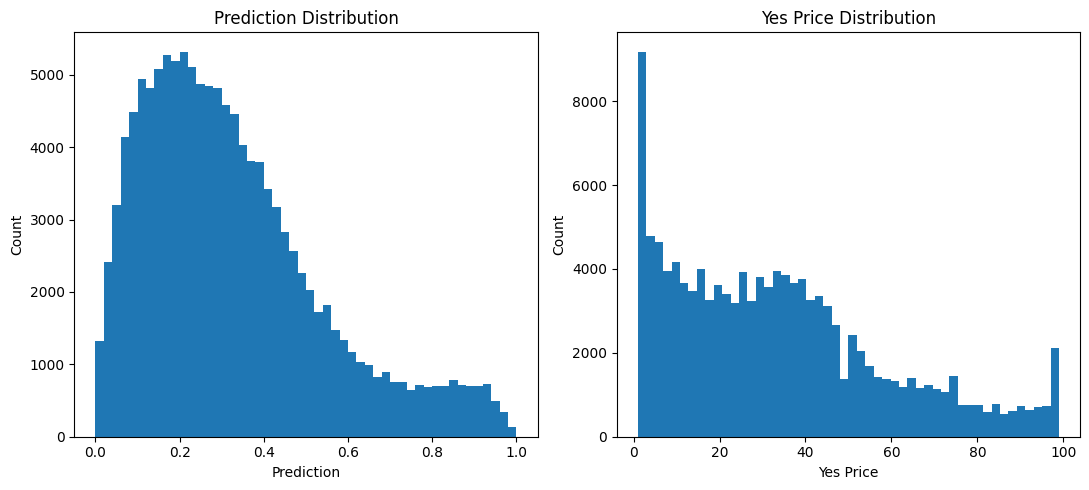

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].hist(pred_df['prediction'], bins=50)
ax[0].set_xlabel('Prediction')
ax[0].set_ylabel('Count')
ax[0].set_title('Prediction Distribution')

ax[1].hist(pred_df['yes_price'], bins=50)
ax[1].set_xlabel('Yes Price')
ax[1].set_ylabel('Count')
ax[1].set_title('Yes Price Distribution')

plt.tight_layout()
plt.show()